In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# These commands below set some options for pandas and to have matplotlib show the charts in the notebook
pd.set_option('display.max_rows', 1000)
pd.options.display.float_format = '{:,.2f}'.format
%matplotlib inline

# Load the data
# We have this defaulted to the folder OUTSIDE of your repo - please change it as needed
contrib = pd.read_csv('2016_ca_primary_cleaned.csv', index_col=False, parse_dates=['contb_receipt_dt'])

# Note - for now, it is okay to ignore the warning about mixed types.

print("Unique candidate names in the dataset:")
print(sorted(contrib['cand_nm'].unique()))
print("\n")

# Checking the date range in the dataset
print("Date range of contributions:")
print("Earliest date:", contrib['contb_receipt_dt'].min())
print("Latest date:  ", contrib['contb_receipt_dt'].max())

print("\nNumber of unique dates:", contrib['contb_receipt_dt'].nunique())

/Users/alexmwamsindo/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (6) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


Unique candidate names in the dataset:
['Bush, Jeb', 'Carson, Benjamin S.', 'Christie, Christopher J.', 'Clinton, Hillary Rodham', "Cruz, Rafael Edward 'Ted'", 'Fiorina, Carly', 'Gilmore, James S III', 'Graham, Lindsey O.', 'Huckabee, Mike', 'Jindal, Bobby', 'Johnson, Gary', 'Kasich, John R.', 'Lessig, Lawrence', "O'Malley, Martin Joseph", 'Pataki, George E.', 'Paul, Rand', 'Perry, James R. (Rick)', 'Rubio, Marco', 'Sanders, Bernard', 'Santorum, Richard J.', 'Stein, Jill', 'Trump, Donald J.', 'Walker, Scott', 'Webb, James Henry Jr.']


Date range of contributions:
Earliest date: 2014-07-22 00:00:00
Latest date:   2016-06-07 00:00:00

Number of unique dates: 524


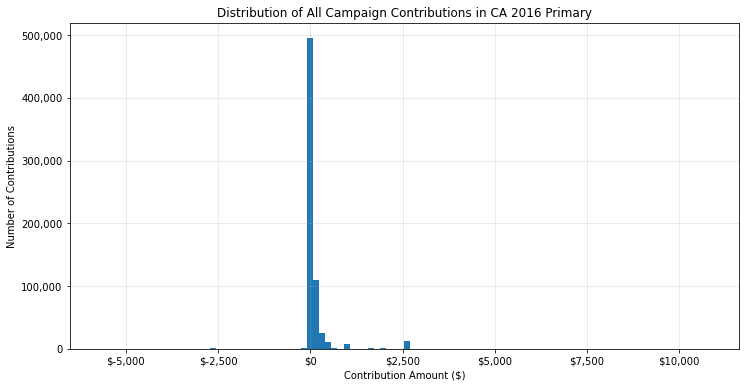

In [2]:
# 1a YOUR CODE HERE

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(contrib['contb_receipt_amt'], bins=100)

ax.set_title('Distribution of All Campaign Contributions in CA 2016 Primary')
ax.set_xlabel('Contribution Amount ($)')
ax.set_ylabel('Number of Contributions')

# Formatting the y-axis with commas (number of contributions)
fmt_y = '{x:,.0f}'
tick_y = mtick.StrMethodFormatter(fmt_y)
ax.yaxis.set_major_formatter(tick_y)

# Also, formatting the x-axis with dollar signs
fmt_x = '${x:,.0f}'
tick_x = mtick.StrMethodFormatter(fmt_x)
ax.xaxis.set_major_formatter(tick_x)

ax.grid(True, alpha=0.3)
plt.show()

## 1a insight

Most donations are really small. The histogram is bunched up on the left with a long tail to the right, which makes sense because most people don't donate thousands of dollars to campaigns.

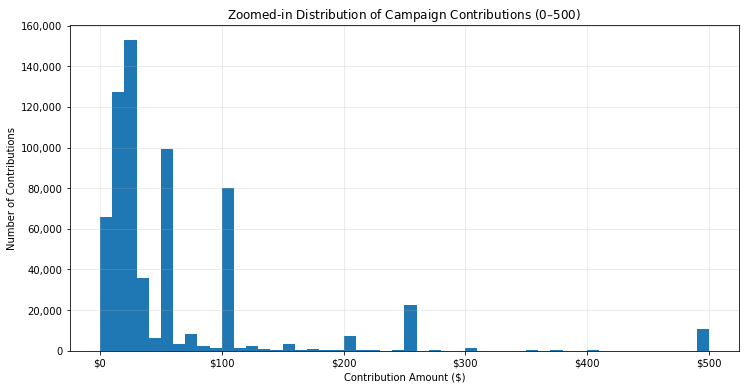

In [3]:
# 1b YOUR CODE HERE

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(contrib['contb_receipt_amt'], bins=50, range=(0, 500))

ax.set_title('Zoomed-in Distribution of Campaign Contributions ($0 – $500)')
ax.set_xlabel('Contribution Amount ($)')
ax.set_ylabel('Number of Contributions')

# Formatting the y-axis with commas
fmt_y = '{x:,.0f}'
tick_y = mtick.StrMethodFormatter(fmt_y)
ax.yaxis.set_major_formatter(tick_y)

# Formatting the x-axis with dollar signs
fmt_x = '${x:,.0f}'
tick_x = mtick.StrMethodFormatter(fmt_x)
ax.xaxis.set_major_formatter(tick_x)

ax.grid(True, alpha=0.3)
plt.show()

# 1b insight

When you zoom in, you can see people really like donating at round numbers `$25`, `$50`, `$100`, `$250`, etc. (very common in FEC data) 

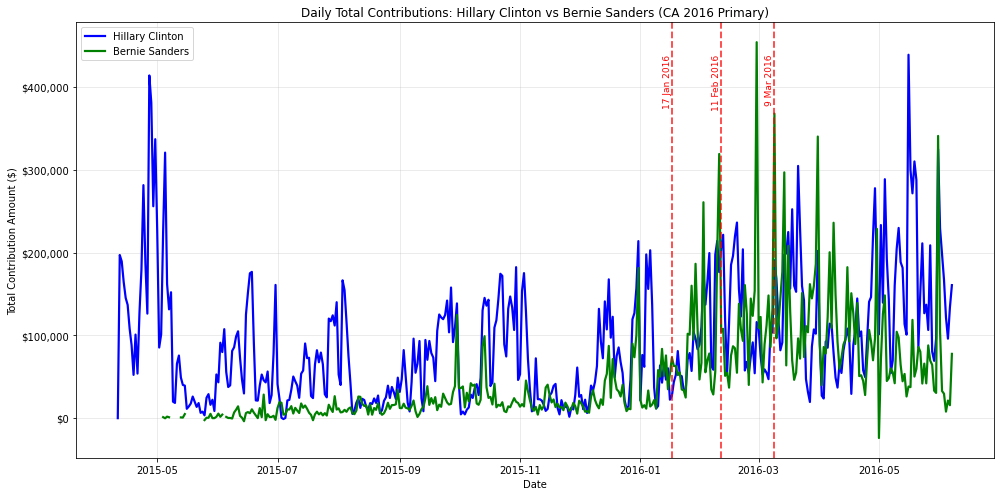

In [4]:
# 1c YOUR CODE HERE

# Now we run the time series line chart with debate vertical lines (final clean version)

import matplotlib.ticker as mtick

# Daily total contributions by candidate
daily = contrib.groupby(['contb_receipt_dt', 'cand_nm'])['contb_receipt_amt'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 7))

# Plotting Clinton and Sanders (using common name variations): 
# Using blue and green colors to represent the democratic party
ax.plot(daily.index, daily['Clinton, Hillary Rodham'], 
        label='Hillary Clinton', color='blue', linewidth=2.2)
ax.plot(daily.index, daily['Sanders, Bernard'], 
        label='Bernie Sanders', color='green', linewidth=2.2)

# Adding vertical lines for the three debates with labels having the dates formatted as per the instructions in the 
# assignment! {'%d/%m/%Y'}
# The date range of contribution is different from what the assignment requires
debates = [
    ('2016-01-17', '17 Jan 2016'),
    ('2016-02-11', '11 Feb 2016'),
    ('2016-03-09', '9 Mar 2016')
]

for date_str, label in debates:
    ax.axvline(pd.to_datetime(date_str), color='red', linestyle='--', alpha=0.75, linewidth=1.8)
    ax.text(pd.to_datetime(date_str), ax.get_ylim()[1]*0.92, label, 
            rotation=90, va='top', ha='right', fontsize=9, color='red')

ax.set_title('Daily Total Contributions: Hillary Clinton vs Bernie Sanders (CA 2016 Primary)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Contribution Amount ($)')

ax.legend()
ax.grid(True, alpha=0.3)

# Format y-axis with dollar signs and commas (tutorial style)
fmt = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmt)
ax.yaxis.set_major_formatter(tick)

plt.tight_layout()
plt.show()

# 1c insight

Debates appear to generate short-term spikes in daily contributions, especially visible for Sanders. Clinton's fundraising is more consistent but generally higher in total volume.

In [5]:
# 2a YOUR CODE HERE

# Which candidate received the largest number/count of contributions?

counts = (contrib
          .groupby('cand_nm')['contb_receipt_amt']
          .count()
          .sort_values(ascending=False))

print("Number of donations per candidate:")
print(counts.to_frame(name="Number of Donations"))

Number of donations per candidate:


,Number of Donations
cand_nm,
"Sanders, Bernard","379,284"
"Clinton, Hillary Rodham","171,104"
"Cruz, Rafael Edward 'Ted'","56,355"
"Carson, Benjamin S.","27,015"
"Rubio, Marco","13,267"
"Fiorina, Carly","4,679"
"Paul, Rand","4,164"
"Trump, Donald J.","3,806"
"Bush, Jeb","3,056"


# 2a insight

Sanders got way more individual donations than anyone else — almost 380,000. Clinton was second with about 171,000. Everyone else was pretty far behind.

In [6]:
# 2b YOUR CODE HERE

# Which candidate raised the most money?

totals = (contrib
          .groupby('cand_nm')['contb_receipt_amt']
          .sum()
          .sort_values(ascending=False))

print("Total amount raised per candidate:")
display(totals.to_frame(name="Total Raised ($)"))

Total amount raised per candidate:


,Total Raised ($)
cand_nm,
"Clinton, Hillary Rodham","38,969,122.68"
"Sanders, Bernard","19,062,998.80"
"Cruz, Rafael Edward 'Ted'","5,926,568.27"
"Rubio, Marco","4,998,700.92"
"Bush, Jeb","3,316,836.83"
"Carson, Benjamin S.","3,022,105.15"
"Fiorina, Carly","1,473,989.42"
"Kasich, John R.","1,471,417.54"
"Trump, Donald J.","868,672.16"


# 2b insight

Even though Sanders had more donations, Clinton raised almost twice as much money total (`$38.9M`vs `$19.1M`). So her donors were giving bigger amounts.

In [7]:
# 2c YOUR CODE HERE

# Merging count and total

# - Looking at the two tables you presented above - if those tables are Series convert them to DataFrames.
# - Rename the variable (column) names to accurately describe what is presented.
# - Merge together your tables to show the *count* and the *value* of donations to each candidate in one table.
# - Hint: Use the `merge` method.

combined = pd.merge(counts, totals, left_index=True, right_index=True)
combined = (combined
            .rename(columns={'contb_receipt_amt_x': 'Number of Donations',
                             'contb_receipt_amt_y': 'Total Raised ($)'})
            .sort_values('Total Raised ($)', ascending=False))

print("Combined table - Count and Total Raised:")
print(combined)

Combined table - Count and Total Raised:


,Number of Donations,Total Raised ($)
cand_nm,,
"Clinton, Hillary Rodham","171,104","38,969,122.68"
"Sanders, Bernard","379,284","19,062,998.80"
"Cruz, Rafael Edward 'Ted'","56,355","5,926,568.27"
"Rubio, Marco","13,267","4,998,700.92"
"Bush, Jeb","3,056","3,316,836.83"
"Carson, Benjamin S.","27,015","3,022,105.15"
"Fiorina, Carly","4,679","1,473,989.42"
"Kasich, John R.","2,957","1,471,417.54"
"Trump, Donald J.","3,806","868,672.16"


# 2c insights

Putting the two tables together makes that contrast really obvious — Sanders wins on volume, Clinton wins on dollars.

In [8]:
# 2d YOUR CODE HERE

# Add average donation to see which candidate had the highest contribution!

combined['Average Donation ($)'] = combined['Total Raised ($)'] / combined['Number of Donations']

print("Candidates sorted by Average Donation:")
print(avg_sorted)

,Number of Donations,Total Raised ($),Average Donation ($)
cand_nm,,,
"Gilmore, James S III",3,"8,100.00","2,700.00"
"Perry, James R. (Rick)",104,"208,400.00","2,003.85"
"Pataki, George E.",20,"30,450.00","1,522.50"
"Christie, Christopher J.",333,"456,066.00","1,369.57"
"Graham, Lindsey O.",305,"379,495.00","1,244.25"
"Bush, Jeb","3,056","3,316,836.83","1,085.35"
"O'Malley, Martin Joseph",392,"297,334.26",758.51
"Jindal, Bobby",31,"23,231.26",749.40
"Walker, Scott",666,"492,706.90",739.80


# 2d insight

The average donation column is interesting. Sanders averaged only `$50` per donation while Clinton averaged `$228`. And then candidates like Gilmore averaged `$2,700` — but only had 3 donations total, so it's basically just a few wealthy donors.

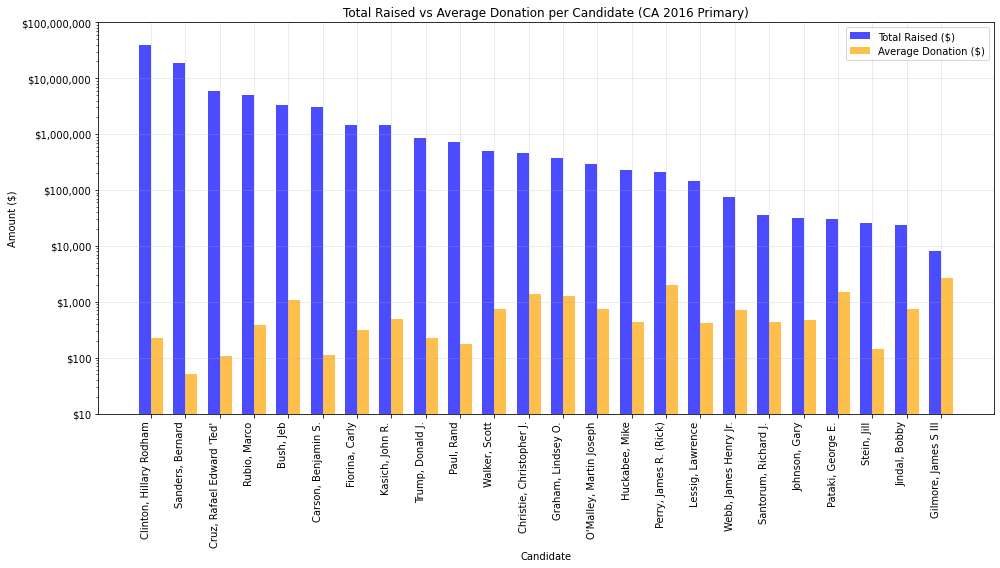

In [9]:
# 2e YOUR CODE HERE

# Make a single bar chart that shows two different bars per candidate with one bar as the total value of the donations and the other as average $ per donation. 
# - Show the Candidates Name on the x-axis
# - Show the amount on the y-axis
# - Include a title
# - Include axis labels
# - Sort by total value of the donations

import matplotlib.ticker as mtick

plot_df = combined.sort_values('Total Raised ($)', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
x = range(len(plot_df))
width = 0.35

ax.bar([i - width/2 for i in x], plot_df['Total Raised ($)'], width=width, 
       label='Total Raised ($)', color='blue', alpha=0.7)
ax.bar([i + width/2 for i in x], plot_df['Average Donation ($)'], width=width, 
       label='Average Donation ($)', color='orange', alpha=0.7)

ax.set_xlabel('Candidate')
ax.set_ylabel('Amount ($)')
ax.set_title('Total Raised vs Average Donation per Candidate (CA 2016 Primary)')
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=90, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')                       # log scale to see both values
ax.set_ylim(10, 100_000_000)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

# 2e insight

The log scale was necessary because the total raised and average donation are so different in magnitude that you can't really see both on a normal scale at the same time.

# 2f

Looking at the data, the biggest takeaway is that Sanders and Clinton had completely opposite fundraising strategies. Sanders had way more donors but they gave much less on average, while Clinton had fewer donors but raised more total money. It's kind of surprising that having twice as many donors doesn't translate to raising more money. The smaller candidates are also interesting — someone like Gilmore only had 3 donations total, which means they basically had no real grassroots support in California at all. Overall it seems like California donors heavily favored the Democratic candidates, since Sanders and Clinton together account for the vast majority of both donations and total money raised.

In [10]:
# 3a YOUR CODE HERE

# Here we are wanting to understand/ get more information about
# the top 5 occupations of individuals that contributed to Hillary Clinton

# - Subset your data to create a dataframe with only donations for Hillary Clinton.
# - Then use the `value_counts` and `head` methods to present the top 5 occupations (`contbr_occupation`) for her donors.
# - Note: we are just interested in the count of donations, not the value of those donations.

# Top 5 occupations for Hillary Clinton
clinton = contrib[contrib['cand_nm'] == 'Clinton, Hillary Rodham']

top5_clinton = (clinton['contbr_occupation']
                .value_counts()
                .head(5))

print("Top 5 occupations for Hillary Clinton:")
print(top5_clinton.to_frame(name="Count"))

Top 5 occupations for Hillary Clinton:


,Count
RETIRED,"35,767"
ATTORNEY,"7,514"
INFORMATION REQUESTED,"4,991"
TEACHER,"3,848"
HOMEMAKER,"3,522"


# 3a insight

"RETIRED" is by far the most common occupation for Clinton donors, with over 35,000 donations. That's more than 4x the next one (ATTORNEY). Retired people probably have more time and money to donate.

In [11]:
# 3b YOUR CODE HERE

def get_donors(df):
    """This function takes a dataframe that contains a variable named contbr_occupation.
    It outputs a Series containing the counts for the 5 most common values of that
    variable."""
    return df['contbr_occupation'].value_counts().head(5)

# 3b insight

The function just wraps the `value_counts().head(5)` logic so you don't have to repeat it for every candidate.

In [12]:
# 3c YOUR CODE HERE

# Now run the `get_donors` function from 3b on subsets of the dataframe corresponding to three candidates. 
# Show each of the three candidates below.

# - Hillary Clinton
# - Bernie Sanders
# - Donald Trump

# 3c
print("Hillary Clinton top 5 occupations:")
print(get_donors(contrib[contrib['cand_nm'] == 'Clinton, Hillary Rodham']).to_frame(name="Count"))

print("\nBernie Sanders top 5 occupations:")
print(get_donors(contrib[contrib['cand_nm'] == 'Sanders, Bernard']).to_frame(name="Count"))

print("\nDonald Trump top 5 occupations:")
print(get_donors(contrib[contrib['cand_nm'] == 'Trump, Donald J.']).to_frame(name="Count"))

Hillary Clinton top 5 occupations:


,Count
RETIRED,"35,767"
ATTORNEY,"7,514"
INFORMATION REQUESTED,"4,991"
TEACHER,"3,848"
HOMEMAKER,"3,522"



Bernie Sanders top 5 occupations:


,Count
NOT EMPLOYED,"98,217"
RETIRED,"15,352"
TEACHER,"10,390"
SOFTWARE ENGINEER,"7,957"
ENGINEER,"7,237"



Donald Trump top 5 occupations:


,Count
RETIRED,"1,719"
INFORMATION REQUESTED,88
CEO,62
SALES,58
OWNER,57


# 3c insight

Sanders' top occupation is "NOT EMPLOYED" with nearly 100,000 donations — which is huge. That's probably students and younger people who don't have jobs yet. Trump's list has "CEO" in the top 5, which you don't really see for the other candidates.

In [13]:
# 3d YOUR CODE HERE

# Finally, use `groupby` to separate the entire dataset by candidate. (10 points)

# - Call .apply(get_donors) on your groupby object, which will apply the function you wrote to each subset of your data.
# - Look at your output and marvel at what pandas can do in just one line!

top_occupations_by_candidate = contrib.groupby('cand_nm').apply(get_donors)

print("Top 5 occupations for EVERY candidate:")
print(top_occupations_by_candidate.to_frame(name="Count"))

Top 5 occupations for EVERY candidate:


# 3d insight

Applying the function across all candidates at once with `groupby().apply()` is pretty powerful for one line of code. You can see "RETIRED" shows up as #1 for almost everybody, but each candidate also has some unique ones that reflect who their supporters actually are

# 3e

The occupation data adds a lot of context to who was actually donating. "RETIRED" showing up as number one for almost every candidate makes sense because retired people tend to have more disposable income and more time to follow politics. What's more interesting is the differences between candidates — Sanders having "NOT EMPLOYED" as his top category with nearly 100,000 donations suggests a lot of his support came from younger people or students who don't have traditional jobs yet. Lessig's top occupation being "SOFTWARE ENGINEER" also makes sense given his platform was heavily focused on tech and internet policy.

# 3f

In section 2, Sanders looked really strong because he had the most donations by far. But looking at the occupation data in section 3, it makes more sense why his average donation was so low — a huge chunk of his donors were not employed, meaning they probably couldn't afford to give much. Clinton's donors being heavily "RETIRED" and "ATTORNEY" explains why her average donation was much higher, since those are people with more financial stability. So the occupation data basically explains the pattern we saw in section 2 — it wasn't just about enthusiasm, it was about who had the money to back it up.